## 1- Document/Text Processing and Embedding Creation

In [28]:
import fitz
from tqdm.auto import tqdm
import random
import pandas as pd
from spacy.lang.en import English
import re
from sentence_transformers import SentenceTransformer

In [2]:
def text_formatter(text):
    cleaned_text = text.replace('\n', ' ').strip()
    return cleaned_text

def open_and_read_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):
        text = page.get_text()
        text = text_formatter(text)
        pages_and_texts.append({'page_number': page_number - 41, 'page_char_count': len(text), 'page_word_count': len(text.split(' ')), 'page_sentence_count_raw': len(text.split('. ')), 'page_token_count': len(text) / 4, 'text': text})

    return pages_and_texts
    
pdf_path = 'human-nutrition-text.pdf'
pages_and_texts = open_and_read_pdf(pdf_path)

0it [00:00, ?it/s]

In [3]:
random.sample(pages_and_texts, k = 1)

[{'page_number': 876,
  'page_char_count': 815,
  'page_word_count': 133,
  'page_sentence_count_raw': 10,
  'page_token_count': 203.75,
  'text': 'Magnesium (mg)  130.0  Niacin(B3) (mg)  8.0  Phosphorus (mg)  500.0  Riboflavin (B2) (mcg)  600.0  Selenium (mcg)  30.0  Thiamine (B1) (mcg)  600.0  Zinc (mg)  5.0  Source:Institute of Medicine. 2006. Dietary Reference Intakes: The  Essential Guide to Nutrient Requirements. Washington, DC: The  National Academies Press. https://doi.org/10.17226/11537. Accessed  December 10, 2017.  Factors Influencing Intake  A number of factors can influence children’s eating habits and  attitudes toward food. Family environment, societal trends, taste  preferences, and messages in the media all impact the emotions  that children develop in relation to their diet. Television  commercials can entice children to consume sugary products, fatty  fast-foods, excess calories, refined ingredients, and sodium.  876  |  Childhood'}]

In [4]:
df = pd.DataFrame(pages_and_texts)

In [5]:
df.describe()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00000,1208.000000,1208.000000,1208.000000,1208.000000
mean,562.50000,1148.004139,198.299669,9.972682,287.001035
std,348.86387,560.382275,95.759336,6.187226,140.095569
min,-41.00000,0.000000,1.000000,1.000000,0.000000
25%,260.75000,762.000000,134.000000,4.000000,190.500000
50%,562.50000,1231.500000,214.500000,10.000000,307.875000
75%,864.25000,1603.500000,271.000000,14.000000,400.875000
max,1166.00000,2308.000000,429.000000,32.000000,577.000000


In [6]:
nlp = English()
nlp.add_pipe('sentencizer')

In [7]:
doc = nlp('This is. Another Sentence. Elephant')
assert(len(list(doc.sents))) == 3

In [8]:
for item in tqdm(pages_and_texts):
    item['sentences'] = list(nlp(item['text']).sents)
    item['sentences'] = [str(sentences) for sentences in item['sentences']]
    item['page_sentence_count_spacy'] = len(item['sentences'])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [9]:
random.sample(pages_and_texts, k = 1)

[{'page_number': 582,
  'page_char_count': 1220,
  'page_word_count': 248,
  'page_sentence_count_raw': 17,
  'page_token_count': 305.0,
  'text': 'Food  Serving Folate (mcg  DFE)  Percent Daily  Value  Beef Liver  3 oz.  215  54  Fortified breakfast  cereals  ¾ c.  400  100  Spinach  ½ c.  131  33  White rice, enriched  ½ c.  90  23  Asparagus  4  spears  85  20  White bread, enriched  1 slice  43  11  Broccoli  2  spears  45  10  Avocado  ½ c.  59  15  Orange juice  6 oz.  35  9  Egg  1 large  22  6  Dietary Supplement Fact Sheet: Folate. National Institute of Health,  Office of Dietary Supplements. https://ods.od.nih.gov/factsheets/ Folate-HealthProfessional/. Updated April 20, 2016. Accessed  October 22, 2017.  Vitamin B12 (Cobalamin)  Vitamin B12 contains cobalt, making it the only vitamin that contains  a metal ion. Vitamin B12 is an essential part of coenzymes. It is  necessary for fat and protein catabolism, for folate coenzyme  function, and for hemoglobin synthesis. An enzyme

In [10]:
df_sentenced = pd.DataFrame(pages_and_texts)
df_sentenced.describe()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,1208.00000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000
mean,562.50000,1148.004139,198.299669,9.972682,287.001035,10.319536
std,348.86387,560.382275,95.759336,6.187226,140.095569,6.300843
min,-41.00000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,260.75000,762.000000,134.000000,4.000000,190.500000,5.000000
50%,562.50000,1231.500000,214.500000,10.000000,307.875000,10.000000
75%,864.25000,1603.500000,271.000000,14.000000,400.875000,15.000000
max,1166.00000,2308.000000,429.000000,32.000000,577.000000,28.000000


In [11]:
sentence_chunk_size = 10

def split_list(input_list, slice_size = sentence_chunk_size):
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

test_list = list(range(25))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [12]:
for item in tqdm(pages_and_texts):
    item['sentence_chunks'] = split_list(item['sentences'])
    item['num_chunks'] = len(item['sentence_chunks'])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [13]:
random.sample(pages_and_texts, k = 1)

[{'page_number': 119,
  'page_char_count': 200,
  'page_word_count': 34,
  'page_sentence_count_raw': 2,
  'page_token_count': 50.0,
  'text': 'An interactive or media element has been  excluded from this version of the text. You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=111  \xa0 The Muscular System  |  119',
  'sentences': ['An interactive or media element has been  excluded from this version of the text.',
   'You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=111  \xa0 The Muscular System  |  119'],
  'page_sentence_count_spacy': 2,
  'sentence_chunks': [['An interactive or media element has been  excluded from this version of the text.',
    'You can  view it online here:  http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=111  \xa0 The Muscular System  |  119']],
  'num_chunks': 1}]

In [14]:
df_sentence_chunked = pd.DataFrame(pages_and_texts)
df_sentence_chunked.describe()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,1208.00000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000
mean,562.50000,1148.004139,198.299669,9.972682,287.001035,10.319536,1.525662
std,348.86387,560.382275,95.759336,6.187226,140.095569,6.300843,0.644397
min,-41.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,260.75000,762.000000,134.000000,4.000000,190.500000,5.000000,1.000000
50%,562.50000,1231.500000,214.500000,10.000000,307.875000,10.000000,1.000000
75%,864.25000,1603.500000,271.000000,14.000000,400.875000,15.000000,2.000000
max,1166.00000,2308.000000,429.000000,32.000000,577.000000,28.000000,3.000000


In [18]:
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item['sentence_chunks']:
        chunk_dict = {}
        chunk_dict['page_number'] = item['page_number']
        joined_sentence_chunk = ''.join(sentence_chunk).replace('  ', ' ').strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)
        chunk_dict['sentence_chunk'] = joined_sentence_chunk
        chunk_dict['chunk_char_count'] = len(joined_sentence_chunk)
        chunk_dict['chunk_word_count'] = len([word for word in joined_sentence_chunk.split(' ')])
        chunk_dict['chunk_token_count'] = len(joined_sentence_chunk) / 4
        pages_and_chunks.append(chunk_dict)

  0%|          | 0/1208 [00:00<?, ?it/s]

In [19]:
random.sample(pages_and_chunks, k = 1)

[{'page_number': 8,
  'sentence_chunk': 'Water There is one other nutrient that we must have in large quantities: water. Water does not contain carbon, but is composed of two hydrogens and one oxygen per molecule of water. More than 60 percent of your total body weight is water. Without it, nothing could be transported in or out of the body, chemical reactions would not occur, organs would not be cushioned, and body temperature would fluctuate widely. On average, an adult consumes just over two liters of water per day from food and drink combined. Since water is so critical for life’s basic processes, the amount of water input and output is supremely important, a topic we will explore in detail in Chapter 4. Micronutrients Micronutrients are nutrients required by the body in lesser amounts, but are still essential for carrying out bodily functions. Micronutrients include all the essential minerals and vitamins. There are sixteen essential minerals and thirteen vitamins (See Table 1.1 “

In [20]:
len(pages_and_chunks)

1843

In [21]:
df_chunked = pd.DataFrame(pages_and_chunks)
df_chunked.describe()

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.000000,1843.000000,1843.000000,1843.000000
mean,583.381443,734.442756,112.333152,183.610689
std,347.788670,447.541546,71.220313,111.885387
min,-41.000000,12.000000,3.000000,3.000000
25%,280.500000,315.000000,44.000000,78.750000
50%,586.000000,746.000000,114.000000,186.500000
75%,890.000000,1118.500000,173.000000,279.625000
max,1166.000000,1831.000000,297.000000,457.750000


In [25]:
min_token_length = 30
for row in df_chunked[df_chunked['chunk_token_count'] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 28.75 | Text: Accessed September 22, 2017. Dietary, Behavioral, and Physical Activity Recommendations for Weight Management | 505
Chunk token count: 14.75 | Text: Folate is also found in legumes, liver, and Pregnancy | 787
Chunk token count: 28.75 | Text: Accessed September 22, 2017. Dietary, Behavioral, and Physical Activity Recommendations for Weight Management | 507
Chunk token count: 19.25 | Text: 2018). Centers for Disease Control and 998 | The Causes of Food Contamination
Chunk token count: 25.25 | Text: view it online here: http://pressbooks.oer.hawaii.edu/ humannutrition2/?p=306 484 | Weight Management


In [26]:
pages_and_chunks_over_min_token_length = df_chunked[df_chunked['chunk_token_count'] > min_token_length].to_dict(orient = 'records')

In [27]:
random.sample(pages_and_chunks_over_min_token_length, k = 2)

[{'page_number': 790,
  'sentence_chunk': 'with more than one fetus are advised to gain even more weight to ensure the health of their unborn babies. Figure 13.2 Areas of weight gain for pregnant women The weight an expectant mother gains during pregnancy is two- thirds to three quarters lean tissue, including the placenta and fetus. Weight gain is not the only major change. A pregnant woman also will find that her breasts enlarge and that she has a tendency to retain water4. 4.\xa0Weight Gain during Pregnancy. Utah Department of Health, Baby Your Baby.http://www.babyyourbaby.org/ 790 | Pregnancy',
  'chunk_char_count': 557,
  'chunk_word_count': 91,
  'chunk_token_count': 139.25},
 {'page_number': 398,
  'sentence_chunk': 'Japanese nurse with dependent children having typical appearance of malnutrition , New Bilibid Prison, September-O ctober 1945 by Unknown / Public Domain word, meaning “starvation.”The syndrome affects more than fifty million children under age five worldwide. It is

In [29]:
embedding_model = SentenceTransformer(model_name_or_path = 'all-mpnet-base-v2', device = 'cuda')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

D:\Jobs\Internship\PureLogics_CMIT\RAG_Agent\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Darab\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [30]:
for item in tqdm(pages_and_chunks_over_min_token_length):
    item['embedding'] = embedding_model.encode(item['sentence_chunk'])

  0%|          | 0/1680 [00:00<?, ?it/s]

In [33]:
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_length)
embeddings_df_save_path = 'text_chunks_and_embeddings.csv'
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index = False)

In [34]:
text_chunks_and_embeddings_df = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embeddings_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,[ 6.74242601e-02 9.02281627e-02 -5.09549957e-...
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,[ 5.52156232e-02 5.92139103e-02 -1.66167133e-...
2,-37,Contents Preface University of Hawai‘i at Māno...,766,114,191.50,[ 2.79801786e-02 3.39814052e-02 -2.06426717e-...
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,142,235.25,[ 6.82566836e-02 3.81275043e-02 -8.46855063e-...
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,[ 3.30264196e-02 -8.49768426e-03 9.57160629e-...


## 2- RAG: Search and Answer

In [19]:
import random
import torch
import ast
import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import util, SentenceTransformer
import textwrap
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available
from transformers import BitsAndBytesConfig

In [2]:
device = 'cuda'

In [3]:
text_chunks_and_embeddings_df = pd.read_csv('text_chunks_and_embeddings.csv')
text_chunks_and_embeddings_df['embedding'] = text_chunks_and_embeddings_df['embedding'].apply(lambda x: np.fromstring(x.strip('[]'), sep = ' ', dtype = np.float32))
pages_and_chunks = text_chunks_and_embeddings_df.to_dict(orient = 'records')
text_chunks_and_embeddings_df['embedding']

0       [0.06742426, 0.09022816, -0.0050954996, -0.031...
1       [0.055215623, 0.05921391, -0.016616713, -0.020...
2       [0.027980179, 0.033981405, -0.020642672, 0.001...
3       [0.06825668, 0.038127504, -0.008468551, -0.018...
4       [0.03302642, -0.008497684, 0.009571606, -0.004...
                              ...                        
1675    [0.018562261, -0.016427794, -0.012704574, -0.0...
1676    [0.033472084, -0.05704407, 0.015148938, -0.010...
1677    [0.07705153, 0.009785581, -0.012181766, 0.0010...
1678    [0.10304517, -0.016470172, 0.008268446, 0.0377...
1679    [0.08637739, -0.012535848, -0.011274668, 0.049...
Name: embedding, Length: 1680, dtype: object

In [4]:
embeddings = np.stack(text_chunks_and_embeddings_df['embedding'].tolist(), axis = 0)
embeddings[0:10], embeddings.shape

(array([[ 6.7424260e-02,  9.0228163e-02, -5.0954996e-03, ...,
         -2.2115497e-02, -2.3213688e-02,  1.2569065e-02],
        [ 5.5215623e-02,  5.9213910e-02, -1.6616713e-02, ...,
         -1.2040647e-02, -1.0284744e-02,  2.2739654e-02],
        [ 2.7980179e-02,  3.3981405e-02, -2.0642672e-02, ...,
         -5.3618532e-03,  2.1256020e-02,  3.1305496e-02],
        ...,
        [ 5.7719678e-02,  4.0385403e-02,  3.6825489e-03, ...,
         -1.4220099e-02, -4.6700402e-03, -9.9831140e-03],
        [ 6.4209826e-02,  2.4101475e-02, -2.1665758e-03, ...,
         -2.4352401e-02, -6.3085608e-05, -1.1271489e-02],
        [ 6.5346807e-02,  1.7753653e-02,  4.3476485e-03, ...,
         -4.2248890e-02,  6.3040323e-04,  1.4488864e-02]],
       shape=(10, 768), dtype=float32),
 (1680, 768))

In [5]:
embedding_model = SentenceTransformer(model_name_or_path = 'all-mpnet-base-v2', device = 'cuda')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [6]:
query = 'Chronic Diseases'
query_embedding = embedding_model.encode(query, convert_to_tensor = True)
dot_scores = util.dot_score(a = query_embedding, b = torch.Tensor(embeddings).to('cuda'))[0]
dot_scores.max(), text_chunks_and_embeddings_df.iloc[dot_scores.argmax().item()].sentence_chunk

(tensor(0.5741, device='cuda:0'),
 'Threats to Health UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM Chronic Diseases Chronic diseases are ongoing, life-threatening, and life-altering health challenges. They are the leading cause of death worldwide. Chronic conditions are increasing in frequency. They cause significant physical and emotional suffering and are an impediment to economic growth and vitality. It is important, now more than ever, to understand the different risk factors for chronic disease and to learn how to prevent their development. The Risk Factors of Chronic Disease A risk factor is a signal that your chances for acquiring a chronic disease may be increased. You might liken a risk factor to the flags that lifeguards sometimes set up at beaches. When you see these flags, you know immediately that swimming within the marked areas could be hazardous, and that if you choose to swim within these parameters anyway, you are

In [7]:
def print_wrapped(text, wrap_length = 80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [8]:
top_results_dot_product = torch.topk(dot_scores, k = 5)

In [9]:
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f'Score: {score:.4f}')
    print('Text:')
    print_wrapped(pages_and_chunks[idx]['sentence_chunk'])
    print(f'Page Number: {pages_and_chunks[idx]["page_number"]}')
    print('\n')

Score: 0.5741
Text:
Threats to Health UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN
NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM Chronic Diseases Chronic diseases
are ongoing, life-threatening, and life-altering health challenges. They are the
leading cause of death worldwide. Chronic conditions are increasing in
frequency. They cause significant physical and emotional suffering and are an
impediment to economic growth and vitality. It is important, now more than ever,
to understand the different risk factors for chronic disease and to learn how to
prevent their development. The Risk Factors of Chronic Disease A risk factor is
a signal that your chances for acquiring a chronic disease may be increased. You
might liken a risk factor to the flags that lifeguards sometimes set up at
beaches. When you see these flags, you know immediately that swimming within the
marked areas could be hazardous, and that if you choose to swim within these
parameters anyway, you are doing so at you

In [10]:
pdf_path = 'human-nutrition-text.pdf'
doc = fitz.open(pdf_path)
page = doc.load_page(1098 + 41)

In [11]:
img = page.get_pixmap(dpi = 300)
doc.close()
img_array = np.frombuffer(img.samples_mv, dtype = np.uint8).reshape((img.h, img.w, img.n))

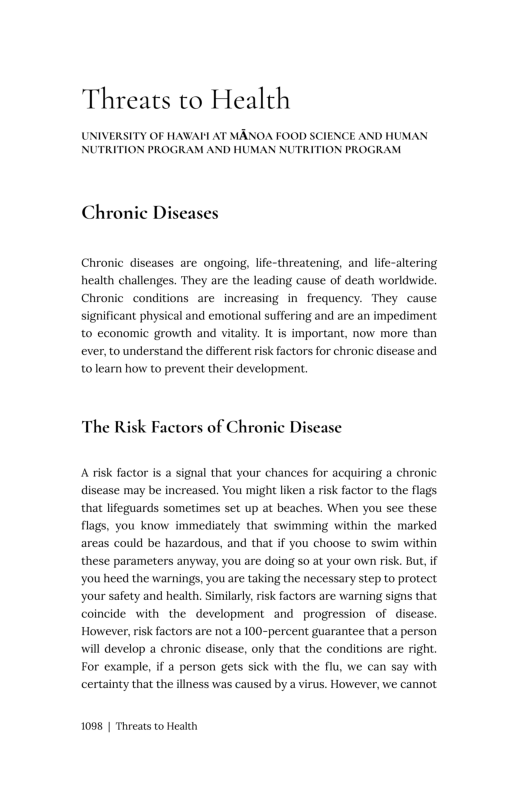

In [12]:
plt.figure(figsize = (13, 10))
plt.imshow(img_array)
plt.axis('off')
plt.show()

In [55]:
def retrieve_relevant_resources(query: str, embeddings: torch.Tensor = embeddings, model: SentenceTransformer = embedding_model, n_resources_to_return: int = 5):
    query_embedding = model.encode(query, convert_to_tensor = True)
    dot_scores = util.dot_score(query_embedding, torch.Tensor(embeddings).to('cuda'))[0]
    scores, indices = torch.topk(input = dot_scores, k = n_resources_to_return)
    return scores, indices

def print_top_results_and_scores(query: str, embeddings: torch.Tensor, pages_and_chunks: list[dict] = pages_and_chunks, n_resources_to_return: int = 5):
    scores, indices = retrieve_relevant_resources(query, embeddings)
    for score, idx in zip(scores, indices):
        print(f'Score: {score:.4f}')
        print('Text:')
        print_wrapped(pages_and_chunks[idx]['sentence_chunk'])
        print(f'Page Number: {pages_and_chunks[idx]["page_number"]}')
        print('\n')

In [14]:
print_top_results_and_scores('Food is beneficial for the health', embeddings)

Score: 0.6798
Text:
effectively. By contrast, eating a variety of foods from all food groups fuels
the body by providing what it needs to produce energy, promote metabolic
activity, prevent micronutrient deficiencies, ward off chronic disease, and
 bolstering a sense of overall health and well-being. Introduction | 1045
Page Number: 1045


Score: 0.6766
Text:
Disease Prevention and Management Eating fresh, healthy foods not only
stimulates your taste buds, but also can improve your quality of life and help
you to live longer. As discussed, food fuels your body and helps you to maintain
a healthy weight. Nutrition also contributes to longevity and plays an important
role in preventing a number of diseases and disorders, from obesity to
cardiovascular disease. Some dietary changes can also help to manage certain
chronic conditions, including high blood pressure and diabetes. A doctor or a
nutritionist can provide guidance to determine the dietary changes needed to
ensure and maintain you

In [15]:
use_quantization_config = True
model_id = 'google/gemma-2b-it'

In [26]:
quantization_config = BitsAndBytesConfig(load_in_4bits = True, bnb_4bit_computer_dtype = torch.float16)
if (is_flash_attn_2_available()) and (torch.cuda.get_device_capability(0)[0] >= 8):
    attn_implementation = 'flash_attention_2'
else:
    attn_implementation = 'sdpa'
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path = model_id)
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path = model_id, torch_dtype = torch.float16, quantization_config = quantization_config, low_cpu_mem_usage = False, attn_implementation = attn_implementation)

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

D:\Jobs\Internship\PureLogics_CMIT\RAG_Agent\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Darab\.cache\huggingface\hub\models--google--gemma-2b-it. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


    Open this URL in your browser:
        https://hf.co/oauth/device

    And enter the code: WL8R-D46U

    Waiting for authorization........................................................


Error: Login failed: Device code expired (timeout). Please try again.
Hint: set HF_DEBUG=1 as environment variable for full traceback.


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

In [27]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): GemmaTextScaledWordEmbedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
 

In [30]:
input_text = 'What are the chronic diseases? How dangerous are they?'
print('Input text:', input_text)
dialogue_template = [{'role': 'user', 'content': input_text}]
prompt = tokenizer.apply_chat_template(conversation = dialogue_template, tokenize = False, add_generation_prompt = True)
print('Prompt:', prompt)

Input text: What are the chronic diseases? How dangerous are they?
Prompt: <bos><start_of_turn>user
What are the chronic diseases? How dangerous are they?<end_of_turn>
<start_of_turn>model



In [32]:
input_ids = tokenizer(prompt, return_tensors = 'pt').to('cuda')
outputs = llm_model.generate(**input_ids, max_new_tokens = 256)

In [33]:
print('Generated tokens:', outputs[0])

Generated tokens: tensor([     2,      2,    106,   1645,    108,   1841,    708,    573,  19424,
         16011, 235336,   2250,  13541,    708,    984, 235336,    107,    108,
           106,   2516,    108,  21404, 235269,   1517, 235303, 235256,    476,
         13367,    576,  19424,  16011,    578,   1024,   5736,  41117, 235292,
           109,    688,  67822,  16011,    688,    708,   1497, 235290,   7617,
          4202,    674,   2001,    604,    978,   1178, 235248, 235304,   4063,
           578,   2952,    614,  56399, 235265,   2365,  17924,    476,   4937,
          2962,   5685,    578,    798,   2389,    577,  30403,    689,  50413,
          4168,   1013,    780,  12461,  10338, 235265,    109,    688,   5393,
          8944,    576,  19424,  16011,   3707,  66058,    109, 235287,   5231,
        114036,  31594,  16011,  66058,  14753,   7197, 235269,  21339, 235269,
          1536,   5330,   5601, 235269,    578,   1536,  45365,    108, 235287,
          5231,  60013

In [34]:
outputs_decoded = tokenizer.decode(outputs[0])
print('Model\'s decoded outputs:', outputs_decoded)

Model's decoded outputs: <bos><bos><start_of_turn>user
What are the chronic diseases? How dangerous are they?<end_of_turn>
<start_of_turn>model
Sure, here's a summary of chronic diseases and their potential dangers:

**Chronic diseases** are long-term conditions that last for more than 3 months and cannot be cured. They pose a significant health risk and can lead to disability or premature death if not managed properly.

**Some examples of chronic diseases include:**

* **Cardiovascular diseases:** Heart disease, stroke, high blood pressure, and high cholesterol
* **Cancer:** Breast cancer, lung cancer, and prostate cancer
* **Diabetes:** Type 1 and type 2 diabetes
* **Chronic respiratory conditions:** Asthma, chronic obstructive pulmonary disease (COPD), and chronic bronchitis
* **Neurological disorders:** Alzheimer's disease, Parkinson's disease, and multiple sclerosis
* **Musculoskeletal disorders:** Back pain, arthritis, and osteoporosis
* **Mental health disorders:** Depression, a

In [35]:
query = 'Give details about the chronic cardiovascular diseases'
scores, indices = retrieve_relevant_resources(query = query, embeddings = embeddings)
scores, indices

(tensor([0.6582, 0.6341, 0.5726, 0.5562, 0.5561], device='cuda:0'),
 tensor([1576, 1569, 1573, 1571,  523], device='cuda:0'))

In [52]:
def prompt_formatter(query, context_items):
    context = '- ' +  '\n- '.join([item['sentence_chunk'] for item in context_items])
    base_prompt = '''Based on the following context items, please answer the query.
    Give yourself room to think by extracting relevant passages from the context before answering the query.
    Don't return the thinking, only return the answer.
    Make sure your answers are as explanatory as possible.
    Use the following examples as reference for the ideal answer style.
    \nExample 1:
    Query: What are the fat-soluble vitamins?
    Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for blood clotting and bone metabolism.
    \nExample 2:
    Query: What are the causes of type 2 diabetes?
    Answer: Type 2 diabetes is often associated with overnutrition, particularly the overconsumption of calories leading to obesity. Factors include a diet high in refined sugars and saturated fats, which can lead to insulin resistance, a condition where the body's cells do not respond effectively to insulin. Over time, the pancreas cannot produce enough insulin to manage blood sugar levels, resulting in type 2 diabetes. Additionally, excessive caloric intake without sufficient physical activity exacerbates the risk by promoting weight gain and fat accumulation, particularly around the abdomen, further contributing to insulin resistance.
    \nExample 3:
    Query: What is the importance of hydration for physical performance?
    Answer: Hydration is crucial for physical performance because water plays key roles in maintaining blood volume, regulating body temperature, and ensuring the transport of nutrients and oxygen to cells. Adequate hydration is essential for optimal muscle function, endurance, and recovery. Dehydration can lead to decreased performance, fatigue, and increased risk of heat-related illnesses, such as heat stroke. Drinking sufficient water before, during, and after exercise helps ensure peak physical performance and recovery.
    \nNow use the following context items to answer the user query:
    {context}
    \nRelevant passages: <extract relevant passages from the context here>
    User query: {query}
    Answer:'''
    prompt = base_prompt.format(context = context, query = query)
    dialogue_template = [{'role': 'user', 'content': prompt}]
    prompt = tokenizer.apply_chat_template(conversation = dialogue_template, tokenize = False, add_generation_prompt = True)
    return prompt
context_items = [pages_and_chunks[i] for i in indices]
prompt = prompt_formatter(query, context_items)
print('Prompt:', prompt)

Prompt: <bos><start_of_turn>user
Based on the following context items, please answer the query.
    Give yourself room to think by extracting relevant passages from the context before answering the query.
    Don't return the thinking, only return the answer.
    Make sure your answers are as explanatory as possible.
    Use the following examples as reference for the ideal answer style.
    
Example 1:
    Query: What are the fat-soluble vitamins?
    Answer: The fat-soluble vitamins include Vitamin A, Vitamin D, Vitamin E, and Vitamin K. These vitamins are absorbed along with fats in the diet and can be stored in the body's fatty tissue and liver for later use. Vitamin A is important for vision, immune function, and skin health. Vitamin D plays a critical role in calcium absorption and bone health. Vitamin E acts as an antioxidant, protecting cells from damage. Vitamin K is essential for blood clotting and bone metabolism.
    
Example 2:
    Query: What are the causes of type 2 diab

In [53]:
input_ids = tokenizer(prompt, return_tensors = 'pt').to('cuda')
outputs = llm_model.generate(**input_ids, temperature = 0.7, do_sample = True, max_new_tokens = 256)
output_text = tokenizer.decode(outputs[0])

In [54]:
print('Query:', query)
print('RAG Answer:', output_text.replace(prompt, '')[5:-5])

Query: Give details about the chronic cardiovascular diseases
RAG Answer: Sure, here's the answer to the user's query:

Cardiovascular disease is the leading cause of death in the United States, with atherosclerosis being a major risk factor. Atherosclerosis is a condition characterized by the buildup of plaque, consisting of fat, cholesterol, calcium, and other substances, in the arteries. Plaque formation leads to the hardening and narrowing of the arteries, which can result in cardiovascular problems such as heart disease and stroke.

The passage also mentions that high blood pressure, obesity, and high cholesterol are all significant risk factors for cardiovascular disease. The passage also provides an overview of some of the more prevalent chronic diseases, including diabetes, heart disease, and cancer.


In [69]:
def ask(query):
    scores, indices = retrieve_relevant_resources(query = query)
    context_items = [pages_and_chunks[i] for i in indices]
    page_numbers = [pages_and_chunks[i]['page_number'] + 41 + 1 for i in indices]
    prompt = prompt_formatter(query, context_items)
    input_ids = tokenizer(prompt, return_tensors = 'pt').to('cuda')
    outputs = llm_model.generate(**input_ids, temperature = 0.7, do_sample = True, max_new_tokens = 256)
    output_text = tokenizer.decode(outputs[0])
    print('Query:', query)
    print('RAG Answer:', output_text.replace(prompt, '')[5:-5])
    print('Relevant Page Numbers:', page_numbers[0], page_numbers[1], page_numbers[2], page_numbers[3], page_numbers[4])

In [64]:
ask('Give details about the chronic cardiovascular diseases.')

Query: Give details about the chronic cardiovascular diseases.
RAG Answer: Sure, here's a summary of the relevant passages from the context:

**Cardiovascular Disease:**

- Cardiovascular disease is associated with an increased risk of heart disease.
- High blood pressure is a major risk factor for cardiovascular disease.
- High cholesterol and obesity are other risk factors.
- Lifestyle factors, such as diet and lack of exercise, can also contribute to the development of cardiovascular disease.

**Other chronic diseases:**

- Type 2 diabetes is linked to obesity and high blood pressure.
- Uncontrolled diabetes can lead to serious health issues, including heart disease, kidney disease, and blindness.
- High cholesterol can increase the risk of heart disease, stroke, and other health problems.
- Osteoporosis is a condition that weakens bones, making them more likely to fracture.
- Obesity is a major risk factor for some chronic diseases, such as heart disease, type 2 diabetes, and cance

In [70]:
ask('Explain some of the fatal aspects related to chronic diseases')

Query: Explain some of the fatal aspects related to chronic diseases
RAG Answer: Sure, here are some of the fatal aspects related to chronic diseases:

- Cardiovascular disease: The leading cause of death worldwide, cardiovascular disease is a result of chronic high blood pressure, high cholesterol, high blood sugar, and obesity.
- Type 2 diabetes: The number one cause of new cases of blindness, lower-limb amputations, and kidney failure, type 2 diabetes is a chronic disease that can lead to serious complications if left untreated.
- Osteoporosis: A condition where bones become weak and brittle, osteoporosis can lead to fractures and decreased mobility in older adults, increasing the risk of falls and other injuries.
- Cancer: Certain chronic diseases, such as breast cancer and prostate cancer, are linked to lifestyle factors like smoking, obesity, and physical inactivity.
- Brain health issues: Chronic conditions like stroke and dementia are associated with aging and increased risk of